# Phase 1.1 - Setup Colab + organisation du dataset
Objectif : configurer l'environnement Colab, telecharger le dataset via l'API Kaggle, organiser les dossiers en train/val par classe, et afficher quelques images pour verifier.

## Configuration du projet

In [51]:
import os

DATA_ROOT = "./data"
RAW_ROOT = DATA_ROOT
train_root = os.path.join(RAW_ROOT, "train")
CLASSES = sorted([d for d in os.listdir(train_root) if os.path.isdir(os.path.join(train_root, d))]) if os.path.isdir(train_root) else []

## Setup de l'API Kaggle (local)
Telechargez kaggle.json depuis Kaggle (Account -> API -> Create New Token) et placez-le dans votre dossier utilisateur ou dans ~/.kaggle/.

In [52]:
!pip install kaggle -q

import os
import shutil

kaggle_dir = os.path.expanduser("~/.kaggle")
kaggle_json = os.path.join(kaggle_dir, "kaggle.json")
alt_kaggle_json = os.path.expanduser("~/kaggle.json")

os.makedirs(kaggle_dir, exist_ok=True)
if os.path.isfile(alt_kaggle_json) and not os.path.isfile(kaggle_json):
    shutil.copy(alt_kaggle_json, kaggle_json)
if not os.path.isfile(kaggle_json):
    raise FileNotFoundError(
        "kaggle.json introuvable. Telechargez-le depuis Kaggle (Account -> API -> Create New Token) "
        "et placez-le dans ~/.kaggle/ ou ~/"
    )
os.chmod(kaggle_json, 0o600)

DEPRECATION: textract 1.6.5 has a non-standard dependency specifier extract-msg<=0.29.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of textract or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
import os
import zipfile

os.makedirs(DATA_ROOT, exist_ok=True)
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition -p "$DATA_ROOT"

zip_path = os.path.join(DATA_ROOT, "fruit-and-vegetable-image-recognition.zip")
extract_dir = DATA_ROOT
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
fruit-and-vegetable-image-recognition.zip: Skipping, found more recently modified local copy (use --force to force download)


## Organisation des dossiers (train/val par classe)

In [54]:
import os
import shutil
import random
from glob import glob

def list_images(path):
    patterns = ["*.jpg", "*.jpeg", "*.png"]
    files = []
    for pattern in patterns:
        files.extend(glob(os.path.join(path, pattern)))
    return files

files_by_class = {cls: list_images(os.path.join(RAW_ROOT, "train", cls)) for cls in CLASSES}
OUTPUT_ROOT = os.path.join(DATA_ROOT, "split")

for split in ["train", "val"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(OUTPUT_ROOT, split, cls), exist_ok=True)

random.seed(42)
splits = {}
for cls, files in files_by_class.items():
    random.shuffle(files)
    split_idx = int(0.8 * len(files))
    splits[cls] = {"train": files[:split_idx], "val": files[split_idx:]}

for cls in CLASSES:
    for src in splits[cls]["train"]:
        shutil.copy(src, os.path.join(OUTPUT_ROOT, "train", cls))
    for src in splits[cls]["val"]:
        shutil.copy(src, os.path.join(OUTPUT_ROOT, "val", cls))

for split in ["train", "val"]:
    for cls in CLASSES:
        path = os.path.join(OUTPUT_ROOT, split, cls)
        print(f"{path} : {len(os.listdir(path))} images")

./data\split\train\apple : 54 images
./data\split\train\banana : 60 images
./data\split\train\beetroot : 70 images
./data\split\train\bell pepper : 72 images
./data\split\train\cabbage : 73 images
./data\split\train\capsicum : 71 images
./data\split\train\carrot : 65 images
./data\split\train\cauliflower : 63 images
./data\split\train\chilli pepper : 69 images
./data\split\train\corn : 69 images
./data\split\train\cucumber : 75 images
./data\split\train\eggplant : 67 images
./data\split\train\garlic : 73 images
./data\split\train\ginger : 54 images
./data\split\train\grapes : 80 images
./data\split\train\jalepeno : 70 images
./data\split\train\kiwi : 70 images
./data\split\train\lemon : 65 images
./data\split\train\lettuce : 77 images
./data\split\train\mango : 68 images
./data\split\train\onion : 75 images
./data\split\train\orange : 55 images
./data\split\train\paprika : 66 images
./data\split\train\pear : 71 images
./data\split\train\peas : 80 images
./data\split\train\pineapple : 7

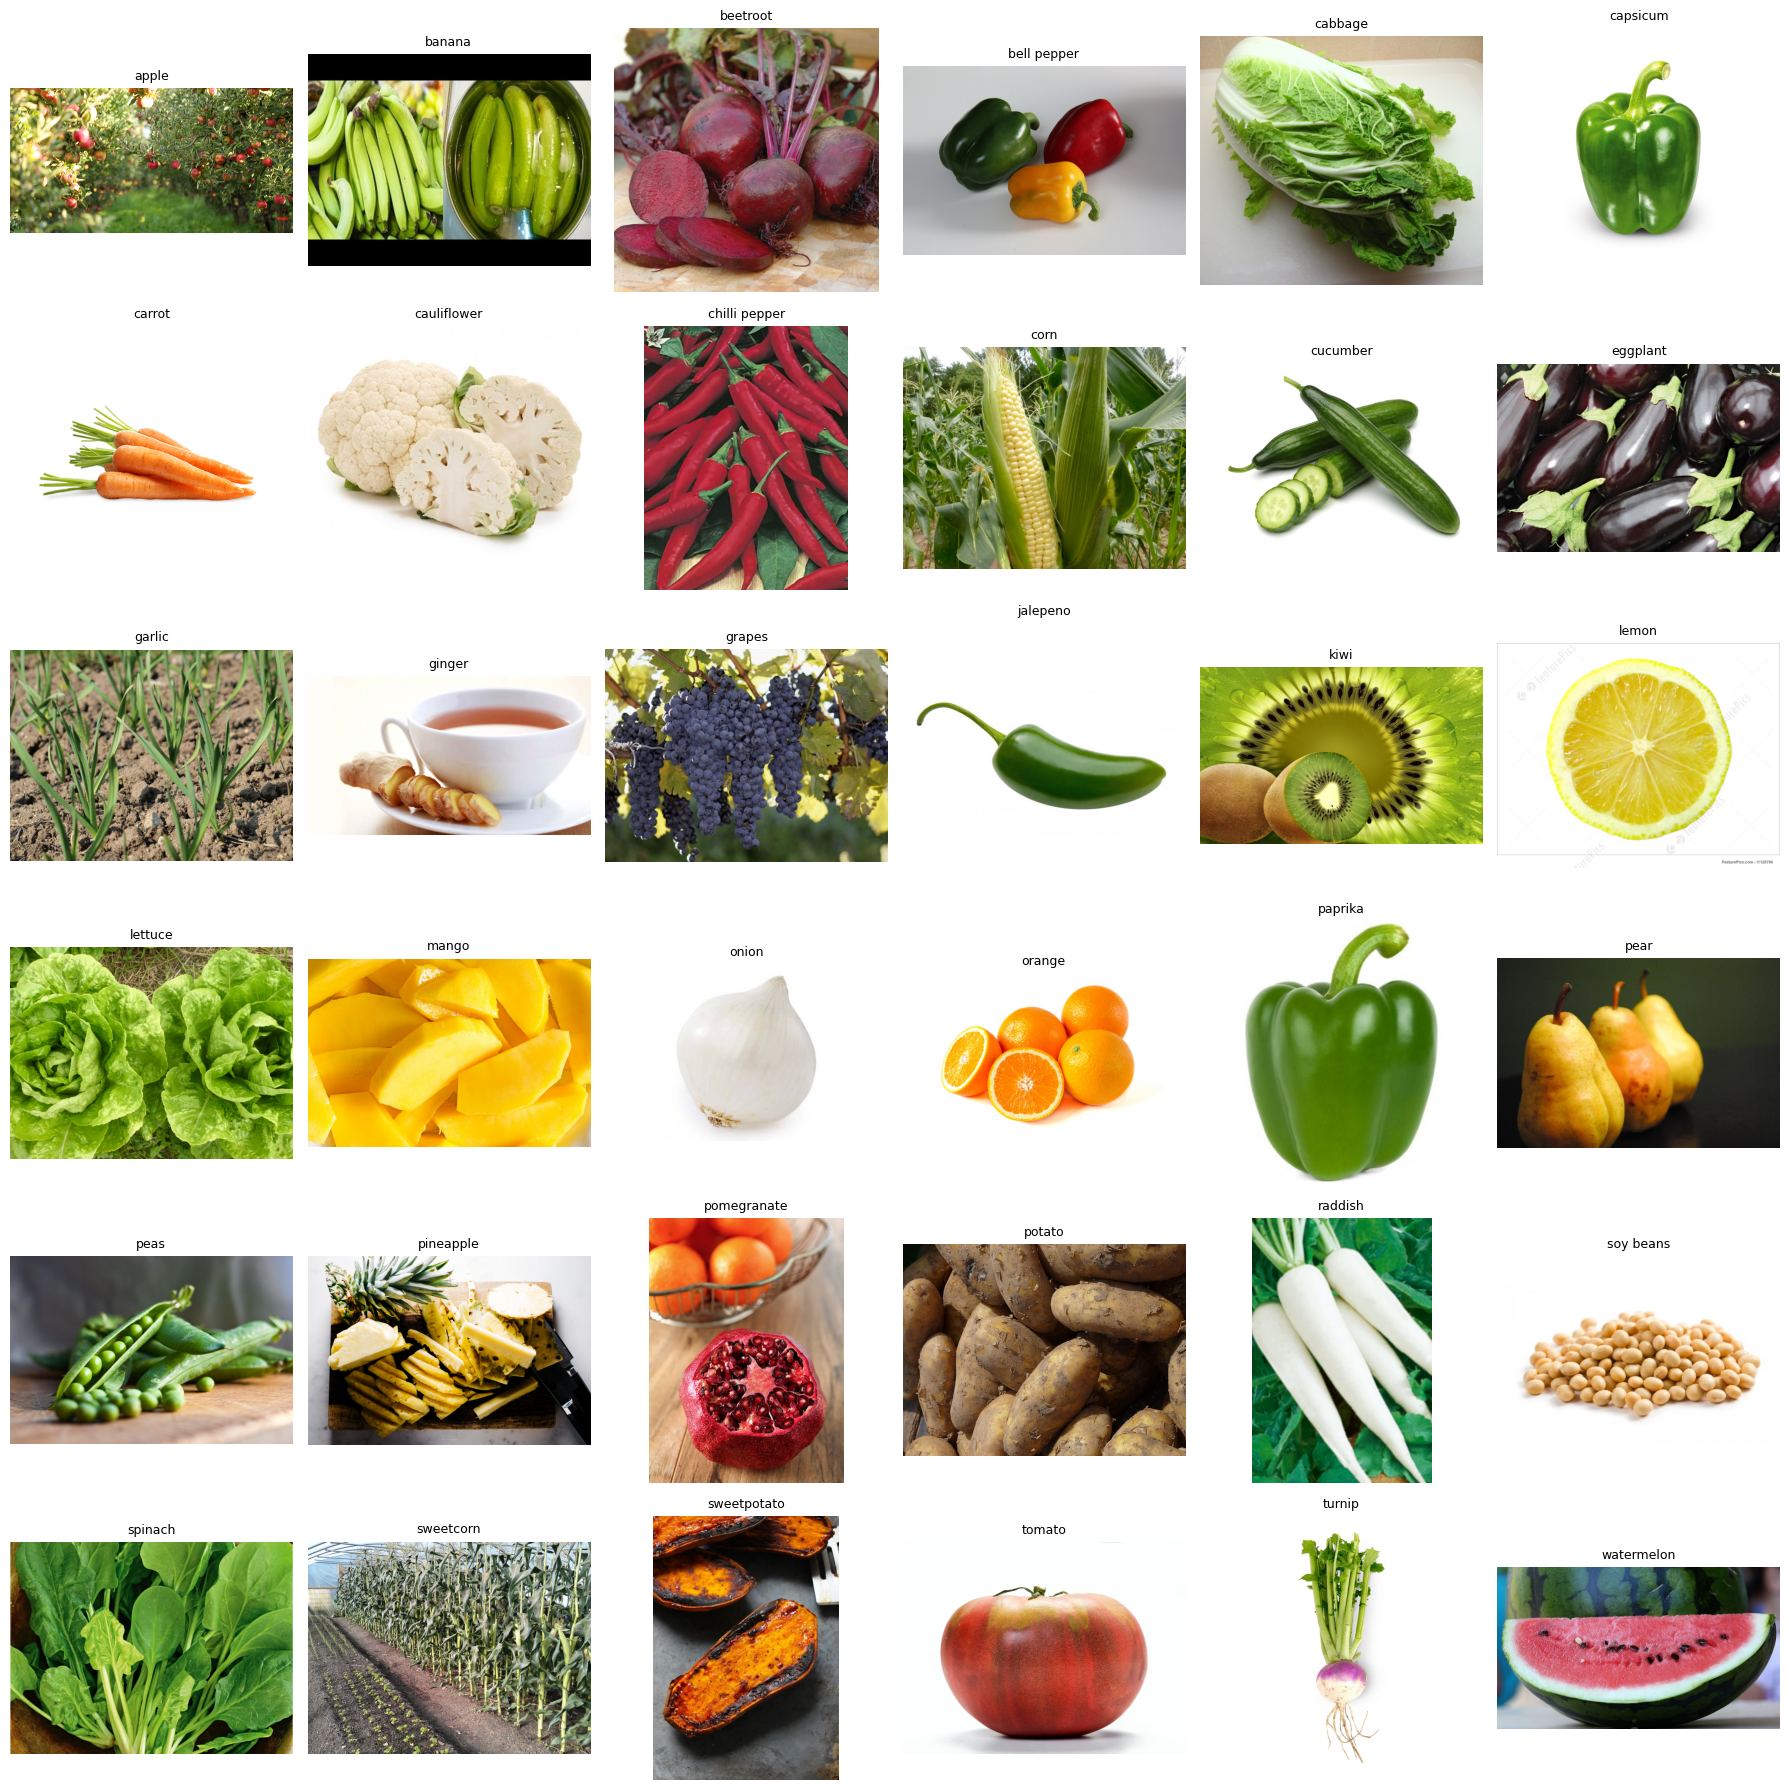

Classes affichees: 36


In [56]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import math

samples = []
for cls in CLASSES:
    files = files_by_class.get(cls, [])
    if files:
        samples.append((cls, random.choice(files)))

num_samples = len(samples)
if num_samples == 0:
    print("Aucune image trouvee. Verifiez que le dataset est bien extrait et que CLASSES n'est pas vide.")
else:
    cols = 6
    rows = math.ceil(num_samples / cols)
    fig = plt.figure(figsize=(3 * cols, 3 * rows))

    for i, (cls, path) in enumerate(samples):
        img = mpimg.imread(path)
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_title(cls, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"Classes affichees: {num_samples}")

## Verifications
Ratio 80/20 respecte, grille 2x3 affichee, shapes finissent par 3 (RGB) ou 1 (gris).
Si erreur kaggle.json, verifier les permissions avec chmod 600 ~/.kaggle/kaggle.json.